# BrushCue Example: Whiten Image

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/whiten_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/whiten-image

In [ ]:
!pip install brushcue

[wgpu] using backend 

Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


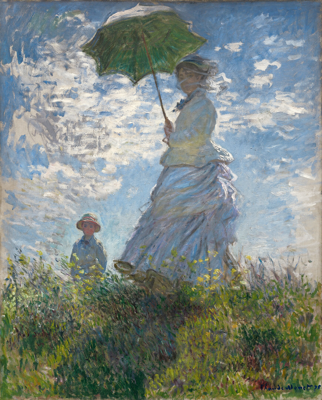

In [1]:
import io
from PIL import Image

import brushcue as bc

strength = 0.6
graph = bc.Composition.monet_women_with_parasol().color_transformer_shader(
    "let w = smoothstep(0.55, 0.95, input.r) * amount;\nreturn vec4<f32>(mix(input.r, 1.0, w), input.g * (1.0 - w), input.b * (1.0 - w), input.a);",
    "",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("amount", strength),
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
